#Diabetes Dataset

Emma Chang


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
import numpy as np
import seaborn as sns
import statsmodels.api as sm

import matplotlib.pyplot as plt

%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


In [36]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# Part 1 - Define your exploratory objective
---

# Exploratory Objective:
We aim to explore the relationships within the diabetes dataset, focusing on identifying the statistical significance of various health-related factors in relation to the occurrence of diabetes.
We seek to establish the statistical significance of the relationships between independent variables such as gender, age, hypertension, heart disease, smoking history, BMI, HbA1c level, blood glucose level, and the outcome variable diabetes. This involves conducting hypothesis tests to determine whether these independent variables are significantly associated with the presence of diabetes.

Effect Magnitude: We are interested in understanding the effect magnitude where we will be identifying which variables among gender, age, hypertension, heart disease, smoking history, BMI, HbA1c level, and blood glucose level have the highest magnitude of effect on the likelihood of having diabetes. This will be determined in terms of the beta coefficient, providing insights into the strength and direction of the relationships.

Effect Variance: We are interested in understanding the effect variance where we will be determining which variables contribute the most to explaining the variation in the occurrence of diabetes. This involves assessing the change in R-squared, helping us understand which factors have the most substantial impact on the variability of the outcome variable.

# Research Questions:
1. How do a combination of health factors, including age, BMI, smoking history, and blood glucose levels, collectively contribute to the likelihood of having diabetes?

#Part 2 - Define your predictive objective
---





We want to be able to identify the best set of predictors among 'gender,' 'age,' 'hypertension,' 'heart_disease,' 'smoking_history,' 'bmi,' 'HbA1c_level,' and 'blood_glucose_level' that contribute significantly to predicting whether an individual has diabetes or not. We also want to be able to identify which models of Logistic, K-Nearest Neighbors, or Random Forest is better at predicting whether the patients have diabetes or not.


Question:
Which models would predict whether the patient has diabetes or not with the most accuracy?


#Part 3 - Sample, data, and variables
---

#2.1

Data Source - Kaggle.Com

Why is it trustworthy?:
Kaggle has a strong reputation within the data science community, and the dataset has a discussion area where the poster answers all questions related to the data.

#2.2

The dataset has 100,000 observations. The observations in this dataset are unique people, and certain traits they exhibit, which can predict if they have diabetes or not.

#2.3

Independent Variables
*   **gender** - The gender of the patient as a string (either male or female)
*   **age** - The age of the patient as a float
*   **hypertension** - Whether the patient has hypertension/high-blood pressure or not (1 means they do and 0 means they don't)
*   **heart_disease** - Whether the patient has heart disease or not (1 means they do and 0 means they don't)
*   **smoking_history** - The patient's history regarding smoking (Values are No Info, never, former, current, not current, ever)
*   **bmi** - The patient's BMI (Body Mass Index) as a float
*   **HbA1c_level** - The patient's blood sugar level as an average over the past 2-3 months, measured as a float
*   **blood_glucose_level** - The patient's concentration of blood glucose in mg/dl, as an int

Outcome Variable
*   **diabetes** - Whether or not the patient has diabetes (1 means they do and 0 means they don't)










In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [38]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


#Part 4 - Data pre-processing
---

# 3.1

In [39]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [40]:
#We observe 3,854 duplicates in our dataset. We decided to drop these to ensure
# accuracy in our results
df.duplicated().sum()

np.int64(3854)

In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df["gender"] = df["gender"].replace("Female", 0)
df["gender"] = df["gender"].replace("Male", 1)
df = df.drop(df[df["gender"] == "Other"].index)
df = df.rename(columns={"gender": "is_male"})

#We decided to drop genders with a value of "other" since they would make it hard to analyze how gender could play a role in causing diabetes.

In [43]:
df

,is_male,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,never,25.19,6.6,140,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0
2,1,28.0,0,0,never,27.32,5.7,158,0
3,0,36.0,0,0,current,23.45,5.0,155,0
4,1,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,No Info,24.60,4.8,145,0
99996,0,2.0,0,0,No Info,17.37,6.5,100,0
99997,1,66.0,0,0,former,27.83,5.7,155,0
99998,0,24.0,0,0,never,35.42,4.0,100,0


In [44]:
df['is_male'] = df['is_male'].astype(str).astype(int)

In [45]:
df["smoking_history"].value_counts()

,count
smoking_history,
never,34395
No Info,32881
former,9299
current,9197
not current,6359
ever,3997


In [46]:
# To help our data be understood by the machine better, we replaced the values for smoking history to numeric values
# People who havent smoked are given a value of 0
# People who have smoked in the past but are not current smokers are assigned 1
# People who are current smokers are assigned 2

df["smoking_history"] = df["smoking_history"].replace("never", 0)
df["smoking_history"] = df["smoking_history"].replace("No Info", 0)
df["smoking_history"] = df["smoking_history"].replace("former", 1)
df["smoking_history"] = df["smoking_history"].replace("not current", 1)
df["smoking_history"] = df["smoking_history"].replace("ever", 1)
df["smoking_history"] = df["smoking_history"].replace("current", 2)


/tmp/ipykernel_2499/41158170.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoking_history"] = df["smoking_history"].replace("current", 2)


In [47]:
df

,is_male,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,2,23.45,5.0,155,0
4,1,76.0,1,1,2,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.8,145,0
99996,0,2.0,0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,1,27.83,5.7,155,0
99998,0,24.0,0,0,0,35.42,4.0,100,0


No missing values to clean up

#Part 5 - Descriptive statistics
---


#4.1 Visualizations

/tmp/ipykernel_2499/1669151001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df, palette='viridis')


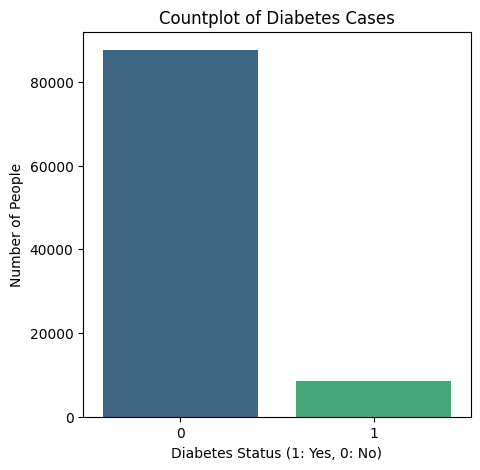

In [48]:
plt.figure(figsize=(5, 5))
sns.countplot(x='diabetes', data=df, palette='viridis')
plt.title('Countplot of Diabetes Cases')
plt.xlabel('Diabetes Status (1: Yes, 0: No)')
plt.ylabel('Number of People')
plt.show()
# We can see that our dataset doesn't have a good number of patients with diabetes
# compared to people who do not have diabetes. This will make it difficult
# for machine learning to properly analyze factors that contribute to diabetes.

Text(0, 0.5, 'Count')

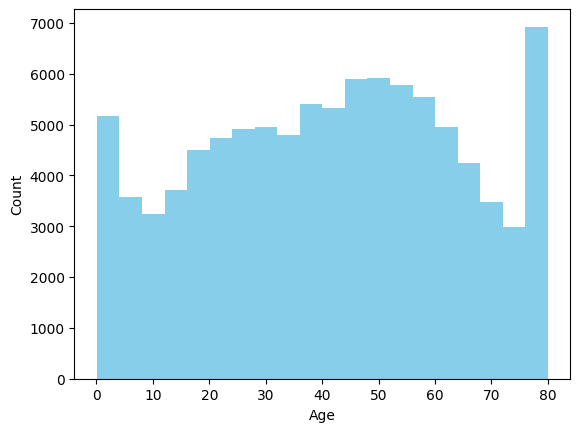

In [49]:
plt.hist(df['age'], bins=20, color='skyblue')
plt.xlabel('Age')
plt.ylabel('Count')
#This histogram shows the age distribution of the patients.

Text(0, 0.5, 'Blood Glucose Level')

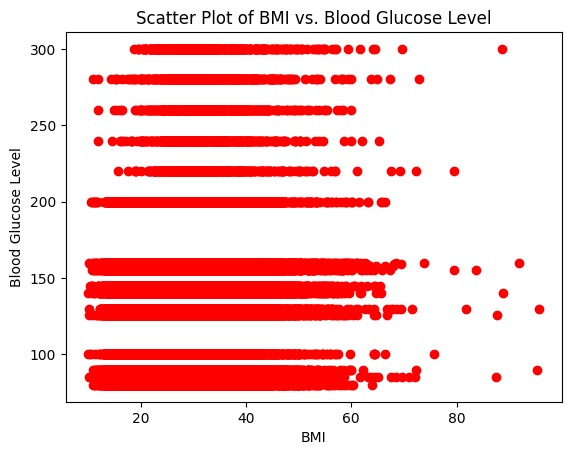

In [50]:
plt.scatter(df['bmi'], df['blood_glucose_level'], color='red')
plt.title('Scatter Plot of BMI vs. Blood Glucose Level')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose Level')

In [51]:
# Correlation
df.corr()

,is_male,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
is_male,1.000000,-0.028670,0.014196,0.078512,0.043925,-0.023490,0.019928,0.017831,0.037837
age,-0.028670,1.000000,0.257297,0.238449,0.177190,0.344779,0.106708,0.114323,0.264918
hypertension,0.014196,0.257297,1.000000,0.119972,0.056579,0.148124,0.081443,0.084841,0.195696
heart_disease,0.078512,0.238449,0.119972,1.000000,0.062203,0.061382,0.068142,0.070838,0.170701
smoking_history,0.043925,0.177190,0.056579,0.062203,1.000000,0.125629,0.027825,0.033661,0.072148
bmi,-0.023490,0.344779,0.148124,0.061382,0.125629,1.000000,0.084443,0.092593,0.214951
HbA1c_level,0.019928,0.106708,0.081443,0.068142,0.027825,0.084443,1.000000,0.171717,0.406446
blood_glucose_level,0.017831,0.114323,0.084841,0.070838,0.033661,0.092593,0.171717,1.000000,0.424366
diabetes,0.037837,0.264918,0.195696,0.170701,0.072148,0.214951,0.406446,0.424366,1.000000


In [52]:
corr = df.corr()

<Axes: >

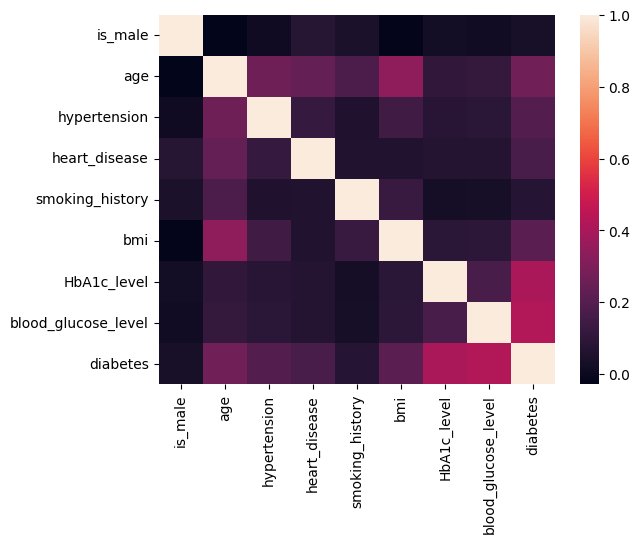

In [53]:
# Correlation Heatmap
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns)

#4.2

1st graph:
From this visualization, we can see that way more people do not have diabetes than those that do have diabetes. This may make it slightly more difficult for machine learning to properly analyze factors that contribute to diabetes.


2nd graph
From this histogram, we are able to see the distribution for age of the patients. We noticed that we have a pretty normal distribution with a couple outliers around 0 and around 80. Without those values, the distribution would remain normal.

3rd scatter plot
Through this scatter plot between BMI and Blood Glucose Level, we can see that we have a good amount of outliers as the BMI value gets higher, especially when the BMI > 80.

4th correlation
We wanted to use this correlation heatmap to see if there were any signs of multicollinearity. However, through this map, we did not find any cases of potential multicollinearity. We checked this with out other measure of correlation and they do match which is great.


#Part 6 - Select appropriate methods for your analysis
---

#6.1

Because we are looking into a binary response wether or not someone has diabetes, we should models such as logistic regression, k nearest neighbors (knn), and random forest.

# 6.2

In [54]:
# Using Logistic Regresssion

y = df['diabetes']
X = df[['is_male', 'age', 'hypertension', 'heart_disease','bmi', 'HbA1c_level', 'blood_glucose_level','smoking_history']]

# Splitting the data
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)

logit = LogisticRegression(max_iter=1000)

logit.fit(X_train, y_train)
y_pred = logit.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[21711   202]
 [  809  1310]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     21913
           1       0.87      0.62      0.72      2119

    accuracy                           0.96     24032
   macro avg       0.92      0.80      0.85     24032
weighted avg       0.96      0.96      0.95     24032



In [55]:
# Using K nearest neighbors (knn)

y = df['diabetes']
X = df[['is_male', 'age', 'hypertension', 'heart_disease','bmi', 'HbA1c_level', 'blood_glucose_level','smoking_history']]
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)


knn = KNeighborsClassifier(n_neighbors=5, n_jobs=8)

# Fitiing the KNN model
knn.fit(X_train, y_train)

# Predict on the validation set
y_pred_knn = knn.predict(X_val.values)

# Evaluate the KNN model
confusion_knn = confusion_matrix(y_val, y_pred_knn)
classification_knn = classification_report(y_val, y_pred_knn)

# Print the results
print("Confusion Matrix (KNN):\n", confusion_knn)
print("\nClassification Report (KNN):\n", classification_knn)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix (KNN):
 [[21748   165]
 [  998  1121]]

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     21913
           1       0.87      0.53      0.66      2119

    accuracy                           0.95     24032
   macro avg       0.91      0.76      0.82     24032
weighted avg       0.95      0.95      0.95     24032



In [56]:
# Using Random Forest
y = df['diabetes']
X = df[['is_male', 'age', 'hypertension', 'heart_disease','bmi', 'HbA1c_level', 'blood_glucose_level','smoking_history']]
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)

rfc = RandomForestClassifier(random_state=0)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))


[[21811   102]
 [  689  1430]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21913
           1       0.93      0.67      0.78      2119

    accuracy                           0.97     24032
   macro avg       0.95      0.84      0.88     24032
weighted avg       0.97      0.97      0.96     24032



#Part 7 - Validate your models
---

#7.1
Looking into our models, we can see that the Random Forest Classifier performed the best out of the three. While all models performed well with classifying people who dont have diabetes, Random Forest Classifier performed the best with finding people who have diabetes. If we look into the recall of all three models, Random Forest Classifier has the highest. Recall is very important and  and the most critical as we don't want to have people think they don't have diabetes when in reality they do.

#Part 8 - Perform analysis and report findings
---

**#8.1 Random Forest**

True Positives (TP): 1445

True Negatives (TN): 21807

False Positives (FP): 106

False Negatives (FN): 674

**Precision:**

Class 0 (No Diabetes): 97% of predicted "No Diabetes" cases are correct.

Class 1 (Diabetes): 93% of predicted "Diabetes" cases are correct.

**Recall:**

Class 0 (No Diabetes): All actual "No Diabetes" cases are identified.

Class 1 (Diabetes): 68% of actual "Diabetes" cases are identified.

F1-Score is 0.97, indicating good overall performance.
Accuracy is 97%, which is the percentage of correctly predicted instances.




#8.2

In [57]:
y = df['diabetes']
X = df[['is_male', 'age', 'hypertension', 'heart_disease',
       'bmi', 'HbA1c_level', 'blood_glucose_level',
       'smoking_history']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               diabetes   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     6585.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:54:39   Log-Likelihood:                 5730.3
No. Observations:               96128   AIC:                        -1.144e+04
Df Residuals:                   96119   BIC:                        -1.136e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.8865    

Our findings show that the features with the largest impact on whether a patient has diabetes or not are heart_disease, hypertension, and HbA1c_level. We can see this in the model results, where all the variables have a p-value less than 0.05, making them statistically significant. The three factors mentioned above have the highest beta coefficients, meaning that they have the largest effect on the outcome variable, which is if a patient has diabetes or not. Since all of these coefficients are positive, these features have a positive relationship with the outcome variable of diabetes. A patient who doesn't have heart disease, high blood pressure, and high HbA1c levels (blood sugar) is less likely to have diabetes and vise versa.

#8.3

As we are diving into our data, we wanted to see if there is a way to take a patients past history and determine if they are at risk of having diabetes. Hospitals and doctors can use our findings to reconize the patterns in a patients history to see if someone would have diabetes. A patient may not recognize that their health is at risk and with this information, doctors can see if they need to test their patient for diabtetes.